# Batch size 2 and the optimizer-update budget

**Prof. Baptista:**

> *"On undertraining, you have more steps but a larger batch size, which leads to fewer optimizer
> updates than their setup. It may be worth rerunning at batch size 2 to match before concluding
> there is no memorization."*

This notebook runs exactly that test.

Baptista et al. (arXiv:2501.15785) train their rectangles U-Net at **batch size 2** for up to
**50,000 optimization steps**, and report that every model size eventually reaches full
memorization. Our earlier sweeps used `batch_size = 8` for 5,000-30,000 steps. The concern is
that the two setups are not matched in *optimizer updates*, so our negative result could be
undertraining rather than genuine generalization.

## Design

Two arms, **matched on update count**, so batch size and update budget are separated:

| arm | batch size | updates | note |
|---|---|---|---|
| `bs2`  | 2 | 100,000 | matches their batch size; 2x their step budget |
| `bs8`  | 8 | 100,000 | our batch size, but the same number of updates |

Both use the baseline architecture `SmallUNet(base_channels=16, num_levels=3)` (195,697
parameters) at `n_train = 8`, with the same sampler, latents, and metric as
`edm_unet_capacity_sweep.ipynb`, so the numbers are directly comparable to what we already
reported.

The comparison this licenses:

- **`bs2` vs `bs8` at the same update count** isolates the effect of batch size.
- **either arm at 30k vs 100k** isolates the effect of the update budget.
- **`bs2` at 50,000** is the direct like-for-like against their reported setup.

## Reading the numbers

A coarse-band score of 0.81 is **not** evidence of memorization. The nearest neighbour is an
`argmin` over `n_train` candidates, so even a model that provably cannot memorize scores below 1.
Two reference lines are computed here and drawn on every plot:

- **held-out real fields** (`holdout_ref`) - fresh samples from the true distribution, scored
  against the training set. They cannot have memorized anything, so this is the *neutral* line.
- **exact GMM score** (`gmm_ref`) - the closed-form empirical-score minimizer, i.e. the fully
  memorizing end of the scale.

Memorization means moving **below the held-out line toward the GMM line**. Prof. Baptista
confirmed the coarse neutral point and the 1/n_train floor are expected artefacts of the
baseline rather than bugs, so the metric is used here with `exclude_nn=True` throughout.

**Runtime:** ~1.1 h for `bs2` + ~2.5 h for `bs8` + ~0.5 h evaluation on MPS (measured on an
M-series Mac). Checkpoints are saved incrementally and training resumes, so the cell can be
re-run after an interruption. `SMOKE = True` verifies the whole pipeline in a couple of minutes.

In [1]:
import sys, os, math, time, copy
import numpy as np
import torch
import matplotlib.pyplot as plt

# -- path setup --
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
src_dir = os.path.join(repo_root, 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import diffusion_score_models as score_models
from multiband_data_utils import generate_multiband_dataset_postmask
from memorization_metrics import RingMetricContext
from edm import EDMPrecond, EDMScoreWrapper, train_edm
from unet import SmallUNet, count_parameters
from device_utils import resolve_device

DEVICE = resolve_device()   # cuda > mps > cpu
print(f'device: {DEVICE}')

device: mps


In [2]:
# -- Data generation (identical config to the earlier memorization notebooks) --
components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]
result = generate_multiband_dataset_postmask(
    num_samples=200, grid_size=128, components=components,
    weights=[1.0, 0.8, 0.8, 1.2], seed=42, normalize=True,
)
bands = result.get('bands', {c['name']: c['band'] for c in components})
N = 128
x_all = result['combined']          # kept on CPU; slices moved to DEVICE as needed
ctx = RingMetricContext(N, bands, device=DEVICE)
print(f'x_all: {tuple(x_all.shape)}')

x_all: (200, 128, 128)


In [3]:
# -- Evaluation: matched sampler (sigma_max=10, same as the capacity sweep) --
VE_SAMPLE = score_models.VE_EDM(sigma_min=0.002, sigma_max=10.0)
N_GEN = 16
N_SDE_STEPS = 1000
N_RAND_REF = 32
LATENT_SEED = 42

@torch.no_grad()
def sample_from(score_fn):
    torch.manual_seed(LATENT_SEED)   # same latents (and step noise stream) for every run
    latents = torch.randn(N_GEN, N*N, device=DEVICE)
    out = VE_SAMPLE.SDEsampler(score_fn, latents, num_steps=N_SDE_STEPS)
    return out.reshape(N_GEN, N, N)

@torch.no_grad()
def pixel_nn_stats(x_gen, x_train):
    '''Relative pixel-space L2 distance to the nearest training field (Baptista-style
    collapse measure). Returns per-sample distances; threshold at plot time.'''
    d = torch.cdist(x_gen.flatten(1), x_train.flatten(1))
    nn_rel = d.min(dim=1).values / x_train.flatten(1).norm(dim=1).mean()
    return nn_rel.cpu()

@torch.no_grad()
def score_against_train(x_gen, x_train):
    m = ctx.evaluate(x_gen, x_train, n_rand_ref=N_RAND_REF, exclude_nn=True)
    return {
        'coarse_score': m['coarse_score'].mean().item(),
        'fine_score': m['fine_score'].mean().item(),
        'mean_ratio': m['mean_ratio'].cpu(),
        'nn_rel': pixel_nn_stats(x_gen, x_train),
    }

@torch.no_grad()
def evaluate_checkpoint(precond, x_train):
    wrapper = EDMScoreWrapper(precond, VE_SAMPLE.marginal_prob_std, N, c_tikhonov=0.0).to(DEVICE)
    x_gen = sample_from(wrapper)
    r = score_against_train(x_gen, x_train)
    r['samples'] = x_gen[:2].cpu()
    return r

@torch.no_grad()
def gmm_reference(x_train):
    '''Fully-memorizing end of the scale: the exact empirical-score minimizer.'''
    train_flat = x_train.reshape(x_train.shape[0], -1)
    gmm = score_models.GMM_score(train_flat, VE_SAMPLE.marginal_prob_mean,
                                 VE_SAMPLE.marginal_prob_std)
    return score_against_train(sample_from(gmm), x_train)

@torch.no_grad()
def holdout_reference(x_train, x_holdout):
    '''Neutral line: real fields the model never saw, scored the same way. They cannot have
    memorized the training set, so whatever they score IS "not memorized" for this n_train.'''
    return score_against_train(x_holdout.to(DEVICE), x_train)

results_dir = os.path.join(repo_root, 'results', 'data')
os.makedirs(results_dir, exist_ok=True)
fig_dir = os.path.join(repo_root, 'results', 'figures')
os.makedirs(fig_dir, exist_ok=True)

In [4]:
# -- Experiment configuration --
SMOKE = False    # True: tiny end-to-end run to verify the pipeline

N_TRAIN = 8
BASE_CHANNELS, EMB_DIM, NUM_LEVELS = 16, 64, 3     # the baseline net, 195,697 params
TOTAL_STEPS = 100_000
CHECKPOINT_AT = [250, 500, 1000, 2000, 4000, 8000, 16000, 30000, 50000, 75000, 100000]

# Two arms, matched on OPTIMIZER UPDATES. 30000 and 50000 are in the checkpoint grid so the
# earlier sweeps and Baptista et al.'s reported budget can both be quoted like-for-like.
ARMS = [
    dict(name='bs2', batch_size=2),
    dict(name='bs8', batch_size=8),
]

if SMOKE:
    TOTAL_STEPS = 400
    CHECKPOINT_AT = [200, 400]
    N_SDE_STEPS = 50
    N_GEN = 4

n_params = count_parameters(SmallUNet(base_channels=BASE_CHANNELS, emb_dim=EMB_DIM,
                                      num_levels=NUM_LEVELS))
print(f'net: C{BASE_CHANNELS}_L{NUM_LEVELS}  {n_params:,} params')
print(f'arms: {[a["name"] for a in ARMS]}  updates: {TOTAL_STEPS:,}')

x_train = x_all[:N_TRAIN].to(DEVICE)
train_flat = x_train.reshape(N_TRAIN, -1)
x_holdout = x_all[100:100 + N_GEN]                 # disjoint from training, same distribution
ckpt_path = os.path.join(results_dir, 'unet_update_budget_checkpoints.pt')

net: C16_L3  195,697 params
arms: ['bs2', 'bs8']  updates: 100,000


In [5]:
# -- Training (checkpoints saved incrementally per arm; re-running resumes) --
all_ckpts = {}
if os.path.exists(ckpt_path):
    all_ckpts = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    print(f'loaded existing checkpoints for {sorted(all_ckpts.keys())}')

make_unet = lambda base_channels, emb_dim: SmallUNet(
    base_channels=base_channels, emb_dim=emb_dim, num_levels=NUM_LEVELS)

for arm in ARMS:
    name = arm['name']
    if name in all_ckpts:
        print(f'{name}: already trained, skipping')
        continue
    print(f"===== training {name} (batch_size={arm['batch_size']}, "
          f"{TOTAL_STEPS:,} updates) =====", flush=True)
    t0 = time.time()
    saved = train_edm(train_flat, grid_size=N, total_steps=TOTAL_STEPS,
                      checkpoint_at=CHECKPOINT_AT, base_channels=BASE_CHANNELS,
                      emb_dim=EMB_DIM, lr=1e-3, batch_size=arm['batch_size'],
                      seed=0, device=DEVICE, UNetClass=make_unet)
    all_ckpts[name] = {
        'config': dict(batch_size=arm['batch_size'], base_channels=BASE_CHANNELS,
                       emb_dim=EMB_DIM, num_levels=NUM_LEVELS, n_params=n_params,
                       total_steps=TOTAL_STEPS),
        'ckpts': {step: {'state_dict': {k: v.cpu() for k, v in p.state_dict().items()},
                         'sigma_data': p.sigma_data}
                  for step, p in saved.items()},
    }
    torch.save(all_ckpts, ckpt_path)
    print(f'  {(time.time()-t0)/60:.1f} min; saved -> {ckpt_path}', flush=True)

===== training bs2 (batch_size=2, 100,000 updates) =====


Estimated sigma_data = 0.9810


  step 1/100000  loss=1.017144


  >> checkpoint saved at step 250


  step 500/100000  loss=0.196765
  >> checkpoint saved at step 500


...

  step 98500/100000  loss=0.012495


  step 99000/100000  loss=0.011612


  step 99500/100000  loss=0.011345


  step 100000/100000  loss=0.022786
  >> checkpoint saved at step 100000


  73.4 min; saved -> /Users/ishittaiyer/Desktop/research-diffusion/results/data/unet_update_budget_checkpoints.pt


In [6]:
# -- Reference lines: what "not memorized" and "fully memorized" actually score --
gmm_ref = gmm_reference(x_train)
holdout_ref = holdout_reference(x_train, x_holdout)
print(f"held-out real fields (neutral)  : coarse={holdout_ref['coarse_score']:.4f} "
      f"fine={holdout_ref['fine_score']:.4f}")
print(f"exact GMM score (memorizing)    : coarse={gmm_ref['coarse_score']:.4f} "
      f"fine={gmm_ref['fine_score']:.4f}")
print(f"\nmemorization = moving BELOW {holdout_ref['coarse_score']:.3f} toward "
      f"{gmm_ref['coarse_score']:.3f} on the coarse band.")

held-out real fields (neutral)  : coarse=0.8412 fine=1.0018
exact GMM score (memorizing)    : coarse=0.0001 fine=0.0085

memorization = moving BELOW 0.841 toward 0.000 on the coarse band.


In [7]:
# -- Evaluation --
eval_results = {}
for name, entry in all_ckpts.items():
    cfg = entry['config']
    print(f"===== evaluating {name} (batch_size={cfg['batch_size']}) =====", flush=True)
    eval_results[name] = {}
    for step, ck in sorted(entry['ckpts'].items()):
        unet = SmallUNet(base_channels=cfg['base_channels'], emb_dim=cfg['emb_dim'],
                         num_levels=cfg['num_levels']).to(DEVICE)
        precond = EDMPrecond(unet, sigma_data=ck['sigma_data']).to(DEVICE)
        precond.load_state_dict(ck['state_dict'])
        precond.eval()
        t0 = time.time()
        r = evaluate_checkpoint(precond, x_train)
        eval_results[name][step] = r
        frac03 = (r['nn_rel'] < 0.3).float().mean().item()
        print(f"  update {step:>7,}: coarse={r['coarse_score']:.4f} fine={r['fine_score']:.4f} "
              f"nn_rel(med)={r['nn_rel'].median():.3f} frac<0.3={frac03:.2f} "
              f"({time.time()-t0:.0f}s)", flush=True)

torch.save({'eval_results': eval_results, 'gmm_ref': gmm_ref, 'holdout_ref': holdout_ref,
            'arms': {a['name']: a for a in ARMS}, 'n_train': N_TRAIN,
            'checkpoint_at': CHECKPOINT_AT, 'total_steps': TOTAL_STEPS,
            'net': dict(base_channels=BASE_CHANNELS, emb_dim=EMB_DIM,
                        num_levels=NUM_LEVELS, n_params=n_params),
            'sampler': {'sigma_max': 10.0, 'n_steps': N_SDE_STEPS, 'latent_seed': LATENT_SEED},
            'note': ('Batch size 2 vs 8 at matched optimizer-update count (100k), n_train=8, '
                     'C16_L3. Tests whether the earlier no-memorization result was undertraining. '
                     'Scored against a held-out neutral line and the exact GMM ceiling.')},
           os.path.join(results_dir, 'unet_update_budget_batchsize.pt'))
print('saved -> unet_update_budget_batchsize.pt')

===== evaluating bs2 (batch_size=2) =====


  update     250: coarse=0.8713 fine=1.0120 nn_rel(med)=1.197 frac<0.3=0.00 (36s)


  update     500: coarse=0.8538 fine=1.0035 nn_rel(med)=1.194 frac<0.3=0.00 (36s)


  update   1,000: coarse=0.8484 fine=1.0084 nn_rel(med)=1.095 frac<0.3=0.00 (36s)


  update   2,000: coarse=0.8547 fine=1.0062 nn_rel(med)=1.202 frac<0.3=0.00 (36s)


...

  update  30,000: coarse=0.8336 fine=0.9992 nn_rel(med)=1.082 frac<0.3=0.00 (34s)


  update  50,000: coarse=0.8297 fine=1.0004 nn_rel(med)=1.056 frac<0.3=0.00 (34s)


  update  75,000: coarse=0.8234 fine=0.9995 nn_rel(med)=1.052 frac<0.3=0.00 (34s)


  update 100,000: coarse=0.8261 fine=1.0003 nn_rel(med)=1.023 frac<0.3=0.00 (34s)


saved -> unet_update_budget_batchsize.pt


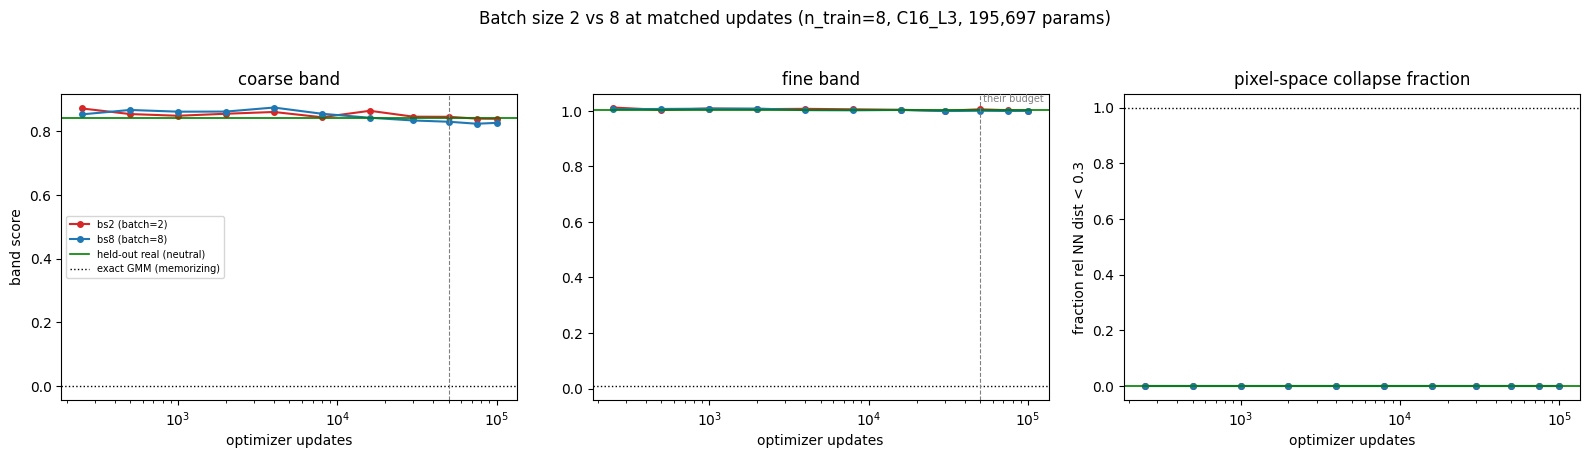

In [8]:
# -- Plots: does batch size 2 or a bigger update budget produce memorization? --
COLORS = {'bs2': 'tab:red', 'bs8': 'tab:blue'}
names = [a['name'] for a in ARMS if a['name'] in eval_results]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, key, title in [(axes[0], 'coarse_score', 'coarse band'),
                       (axes[1], 'fine_score', 'fine band')]:
    for name in names:
        steps = sorted(eval_results[name].keys())
        ys = [eval_results[name][s][key] for s in steps]
        ax.plot(steps, ys, marker='o', ms=4, color=COLORS.get(name),
                label=f"{name} (batch={all_ckpts[name]['config']['batch_size']})")
    ax.axhline(holdout_ref[key], color='green', lw=1.2, ls='-',
               label='held-out real (neutral)')
    ax.axhline(gmm_ref[key], color='black', lw=1.0, ls=':', label='exact GMM (memorizing)')
    ax.axvline(50000, color='gray', lw=0.8, ls='--')
    ax.set_xscale('log')
    ax.set_xlabel('optimizer updates')
    ax.set_title(title)
axes[0].set_ylabel('band score')
axes[0].legend(fontsize=7)
axes[1].text(50000, axes[1].get_ylim()[1], ' their budget', fontsize=7,
             va='top', color='gray')

ax = axes[2]
for name in names:
    steps = sorted(eval_results[name].keys())
    ys = [(eval_results[name][s]['nn_rel'] < 0.3).float().mean().item() for s in steps]
    ax.plot(steps, ys, marker='o', ms=4, color=COLORS.get(name), label=name)
ax.axhline((holdout_ref['nn_rel'] < 0.3).float().mean().item(), color='green', lw=1.2)
ax.axhline((gmm_ref['nn_rel'] < 0.3).float().mean().item(), color='black', lw=1.0, ls=':')
ax.set_xscale('log')
ax.set_xlabel('optimizer updates')
ax.set_ylabel('fraction rel NN dist < 0.3')
ax.set_title('pixel-space collapse fraction')

fig.suptitle(f'Batch size 2 vs 8 at matched updates (n_train={N_TRAIN}, '
             f'C{BASE_CHANNELS}_L{NUM_LEVELS}, {n_params:,} params)', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'unet_update_budget_batchsize.png'), dpi=150,
            bbox_inches='tight')
plt.show()

In [9]:
# -- The summary table to put in the email / paper --
def row(label, r):
    return (f"{label:<34s} {r['coarse_score']:>8.4f} {r['fine_score']:>8.4f} "
            f"{float(r['nn_rel'].median()):>10.3f}")

# quote the milestone budgets that exist in this run: our earlier sweeps ended at 30k,
# Baptista et al. report to 50k, and the final checkpoint is the strongest test.
avail = sorted(set().union(*(set(eval_results[n]) for n in names)))
milestones = [s for s in (30000, 50000) if s in avail] + [avail[-1]]
milestones = sorted(set(milestones))

print(f"{'':<34s} {'coarse':>8s} {'fine':>8s} {'nn_rel med':>10s}")
print('-' * 64)
print(row('held-out real (NEUTRAL)', holdout_ref))
for name in names:
    bs = all_ckpts[name]['config']['batch_size']
    for step in milestones:
        if step in eval_results[name]:
            print(row(f'{name} (batch={bs}) @ {step:,} updates', eval_results[name][step]))
print(row('exact GMM score (MEMORIZING)', gmm_ref))
print('-' * 64)
print('below the neutral line and toward the GMM line = memorization')

# The single number that answers the email: bs2 at their own budget vs the neutral line.
key = 50000 if 50000 in eval_results.get('bs2', {}) else (avail[-1] if 'bs2' in eval_results else None)
if key is not None:
    d = eval_results['bs2'][key]['coarse_score'] - holdout_ref['coarse_score']
    span = gmm_ref['coarse_score'] - holdout_ref['coarse_score']
    print(f"\nbs2 @ {key:,} updates is {d:+.4f} from the neutral line on the coarse band "
          f"({100*d/span:.1f}% of the way to full memorization).")

                                     coarse     fine nn_rel med
----------------------------------------------------------------
held-out real (NEUTRAL)              0.8412   1.0018      1.108
bs2 (batch=2) @ 30,000 updates       0.8455   1.0004      1.052
bs2 (batch=2) @ 50,000 updates       0.8451   1.0055      1.086
bs2 (batch=2) @ 100,000 updates      0.8389   1.0009      1.069
bs8 (batch=8) @ 30,000 updates       0.8336   0.9992      1.082
bs8 (batch=8) @ 50,000 updates       0.8297   1.0004      1.056
bs8 (batch=8) @ 100,000 updates      0.8261   1.0003      1.023
exact GMM score (MEMORIZING)         0.0001   0.0085      0.002
----------------------------------------------------------------
below the neutral line and toward the GMM line = memorization

bs2 @ 50,000 updates is +0.0039 from the neutral line on the coarse band (-0.5% of the way to full memorization).


## Notes

**What answers Prof. Baptista's question.** Compare the `bs2` curve at 50,000 updates against
the held-out neutral line. If it sits at the neutral line, batch size 2 at their own step budget
does not produce memorization here, and the undertraining explanation is ruled out. If it drops
toward the GMM line, our earlier sweeps were undertrained and the negative result does not stand.

**Read against the neutral line, not against 1.0.** The coarse band is the one where this matters
most: held-out real fields score well below 1 because the nearest neighbour is a minimum over
`n_train` candidates. Reporting "coarse = 0.81" without the neutral line invites exactly the
misreading Prof. Baptista already flagged as an expected baseline artefact.

**A caveat on the `bs8` arm.** `train_edm` draws minibatch indices with `torch.randint`, i.e.
*with replacement*. At `batch_size = 8` with `n_train = 8` that is a bootstrap resample - about
63% distinct images per step - not a full pass over the training set. This does not affect the
`bs2` arm (any 2 of 8 is a legitimate minibatch either way) and it does not affect the comparison
at matched update count, but the `bs8` arm should not be described as "full batch" in the writeup.

**Single seed.** Both arms run at `seed=0`. Seed variation on this pipeline is comparable in size
to the effects being resolved, so a difference between the two arms smaller than roughly 0.03 on
the coarse band should not be interpreted until `capacity_multiseed.ipynb` has quantified the
per-seed spread.

**If this arm does show memorization**, the natural follow-up is the same two arms at
`n_train = 2`, which is Baptista et al.'s most extreme memorization setting and where the effect
should be largest.